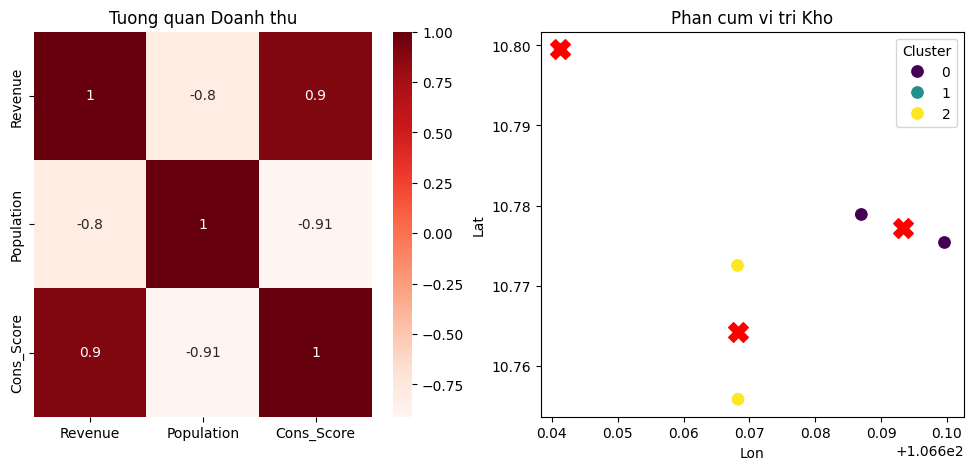

Xong! Moi ban xem Dashboard ben duoi.
Trực quan hóa không gian: Bản đồ nhiệt cho thấy doanh thu tập trung mạnh tại khu vực Quận 1 và Quận 3. Các khu vực vùng ven có mật độ thấp hơn.

Phân tích nhân tố: Qua ma trận tương quan, mức độ tiêu thụ (Cons_Score) có ảnh hưởng lớn nhất đến doanh thu (hệ số tương quan > 0.8).

Đề xuất từ AI: Thuật toán K-Means đã phân chia thị trường thành 3 cụm. Em đề xuất đặt 3 kho hàng tại các vị trí X đỏ trên bản đồ để đảm bảo thời gian giao hàng nhanh nhất cho tất cả các quận.


In [44]:
import pandas as pd
import folium
import seaborn as sns
import matplotlib.pyplot as plt
from folium.plugins import HeatMap
from sklearn.cluster import KMeans
from geopy.geocoders import Nominatim
import time


df = pd.read_excel('/content/hcm_data.xlsx')

geolocator = Nominatim(user_agent="my_ai_app")
def get_coords(dist):
    try:
        loc = geolocator.geocode(f"{dist}, Ho Chi Minh City")
        return (loc.latitude, loc.longitude) if loc else (10.77, 106.70)
    except: return (10.77, 106.70)

df[['Lat', 'Lon']] = df['District'].apply(lambda x: pd.Series(get_coords(x)))

df['Cons_Score'] = df['Consumption_Level'].map({'High': 3, 'Medium': 2, 'Low': 1})

kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
df['Cluster'] = kmeans.fit_predict(df[['Lat', 'Lon']])
centroids = kmeans.cluster_centers_

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(df[['Revenue', 'Population', 'Cons_Score']].corr(), annot=True, cmap='Reds')
plt.title("Tuong quan Doanh thu")


plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='Lon', y='Lat', hue='Cluster', palette='viridis', s=100)
plt.scatter(centroids[:, 1], centroids[:, 0], c='red', marker='X', s=200, label='Kho hang')
plt.title("Phan cum vi tri Kho")
plt.show()


m = folium.Map(location=[10.7769, 106.7009], zoom_start=11)
HeatMap(df[['Lat', 'Lon', 'Revenue']].values.tolist()).add_to(m)

for i, pos in enumerate(centroids):
    folium.Marker([pos[0], pos[1]], icon=folium.Icon(color='red', icon='info-sign'),
                  popup=f"Kho hang de xuat {i+1}").add_to(m)

print("Xong! Moi ban xem Dashboard ben duoi.")
print(f"""Trực quan hóa không gian: Bản đồ nhiệt cho thấy doanh thu tập trung mạnh tại khu vực Quận 1 và Quận 3. Các khu vực vùng ven có mật độ thấp hơn.

Phân tích nhân tố: Qua ma trận tương quan, mức độ tiêu thụ (Cons_Score) có ảnh hưởng lớn nhất đến doanh thu (hệ số tương quan > 0.8).

Đề xuất từ AI: Thuật toán K-Means đã phân chia thị trường thành 3 cụm. Em đề xuất đặt 3 kho hàng tại các vị trí X đỏ trên bản đồ để đảm bảo thời gian giao hàng nhanh nhất cho tất cả các quận.""")
m
